# Large assignment 2

## Read before you start

* Provide clear and complete answers in code blocks or markdown. You may add as many as you need.
* Always motivate your answers. This can be done in markdown cells, or in comments in code.
* Submit your results via Brightspace. Use the following filename convention: ``StudentName1_snumber1_StudentName2_snumber2_LargeAssignment2.ipynb``.
* Make sure you submit a fully executed version of the notebook file. The teaching assistants will not run/debug your code during grading.
* Questions? Ask them during the workgroups, or see Brightspace for instructions on how to proceed.

In [1]:
!apt-get update
!apt install jags -y
!pip install pyjags

Get:1 http://deb.debian.org/debian bullseye InRelease [116 kB]
Get:2 http://deb.debian.org/debian-security bullseye-security InRelease [27.2 kB]
Get:3 http://deb.debian.org/debian bullseye-updates InRelease [44.1 kB]
Get:4 http://deb.debian.org/debian bullseye/main amd64 Packages [8,066 kB]
Get:5 http://deb.debian.org/debian-security bullseye-security/main amd64 Packages [363 kB]
Get:6 http://deb.debian.org/debian bullseye-updates/main amd64 Packages [18.8 kB]
Fetched 8,635 kB in 2s (5,329 kB/s)




The following additional packages will be installed:
  libblas3 libgfortran5 liblapack3
The following NEW packages will be installed:
  jags libblas3 libgfortran5 liblapack3
0 upgraded, 4 newly installed, 0 to remove and 8 not upgraded.
Need to get 4,613 kB of archives.
After this operation, 14.0 MB of additional disk space will be used.
Get:1 http://deb.debian.org/debian bullseye/main amd64 libblas3 amd64 3.9.0-3+deb11u1 [153 kB]
Get:2 http://deb.debian.org/debian bullseye/main amd64 libgf

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pyjags as pj

print('Using PyJAGS v{:s}'.format(pj.__version__))

plt.rc('axes', titlesize=18)        # fontsize of the axes title
plt.rc('axes', labelsize=18)        # fontsize of the x and y labels
plt.rc('xtick', labelsize=14)       # fontsize of the tick labels
plt.rc('ytick', labelsize=14)       # fontsize of the tick labels
plt.rc('legend', fontsize=12)       # legend fontsize
plt.rc('figure', titlesize=30)      # fontsize of the figure title

Using PyJAGS v1.3.8


# 1. Dentistry

## 1.1 The pilot study

The company DentoCare has developed a new toothbrush, the 'Dentinator 2000'. The toothbrush is first being introduced in France. After DentoCare has introduced the toothbrush to the market, they polled a number of French dentists and asked whether they prefer the Dentinator 2000 or its predecessor, the 'Dentinator Pro'.

The results from the poll are that out of $N_F=238$ French dentists, $z_F=187$ say they recommend the new toothbrush. 

DentoCare assumes that, if the Dentinator is performing equal to its predecessor, the recommendations would be 50/50 in favor or against the new toothbrush. To test whether the dentists really prefer the new toothbrush, DentoCare performs Bayesian model comparison.

They define two models, $m_1$, in which there is a preference, and $m_0$ in which the recommendations are pretty much 50/50. In both models, the company uses a binomial likelihood:

$$
    p(z=k \mid N, \theta) = \binom{N}{z} \theta^z (1-\theta)^{N-z} \enspace.
$$

For the null model, DentoCare uses a spike distribution with $c=0.5$:

$
    p(\theta \mid c) = \text{spike}(\theta \mid c) = 
    \begin{cases}
    1 & \text{if } \theta=c \\ 
    0 & \text{otherwise}
    \end{cases} 
$ as the prior.


For the alternative model, they use our familiar beta distribution as a prior instead:

$
    p(\theta \mid a, b) = \frac{1}{B(a,b)} \theta^{a-1} (1-\theta)^{b-1} 
$

In this setting, the Bayes factor $BF_{10}$ can be computed exactly, because of the chosen priors. To compute $BF_{10}$, we need the marginal likelihoods of both models.

1. Derive the expression for the marginal likelihood of $m_1$, $p(z \mid N, m_1)$, in terms of $a, b, z, N$.

_ANSWER:_ 
The formula for the marginal likelihood is:

$$
p(z \mid N, m_1) = \int p(z \mid N, \theta) p(\theta \mid a, b) d\theta 
$$

By plugging in both $p(z \mid N, \theta)$ and $p(\theta \mid a, b)$, the formula becomes:

$$
p(z \mid N, m_1) = \int \binom{N}{z} \theta^z (1-\theta)^{N-z} \frac{1}{B(a,b)} \theta^{a-1} (1-\theta)^{b-1} d\theta
$$

$\theta$ is a probability that can only take values between 0 and 1, so the integral is over this interval as well. The terms in the function can also be further simplified and we get the following expression for the marginal likelihood:

$$
\begin{align*}
p(z \mid N, m_1) &= \binom{N}{z} \frac{1}{B(a,b)} \int_0^1  \theta^z (1-\theta)^{N-z} \theta^{a-1} (1-\theta)^{b-1} d\theta\\
\\
&= \binom{N}{z} \frac{1}{B(a,b)} \int_0^1 \theta^{z+a-1} (1-\theta)^{N-z+b-1} d\theta\\
\\
&= \binom{N}{z} \frac{1}{B(a,b)} B(z+a, N-z+b) \\
\\
&= \binom{N}{z} \frac{ B(z+a, N-z+b)}{B(a,b)}
\end{align*}
$$

2. Similarly, derive the expression for the marginal likelihood of $m_0$, $p(z \mid N, m_0)$ in terms of $c, z, N$.

_ANSWER:_
Like in the first exercise, we use the general formula and plug in the specific functions for this model and try to simplify the integral. Since the spike function is 0 unless $\theta=c$, we only need to compute the marginal likelihood for $\theta=c$ (cause otherwise its 0):

$$
\begin{align}
p(z \mid N, m_0) &= \int p(z \mid N, \theta) p(\theta \mid c) d\theta\\
\\
&= \binom{N}{z} \int_0^1  \theta^z (1-\theta)^{N-z} \text{spike}(\theta \mid c) d\theta\\
\\
&= \binom{N}{z} c^z (1-c)^{N-z}
\end{align}
$$

__Practical note:__

You are almost ready to compute the Bayes factor. However, there is one important caveat: some terms in the marginal likelihood can result in numerical issues. For example $\binom{238}{187}\approx 3.19 \times 10^{52}$, and when working with such huge numbers, we might run into numerical under- and overflow. In practice, we therefore often compute the _log_ marginal likelihoods and _log_ Bayes factor. From basic algebra it follows that

$$
 \log BF_{10} = \log \left(\frac{p(z \mid N, m_1)}{p(z \mid N, m_0)} \right) = \log p(z \mid N, m_1) - \log p(z \mid N, m_0) \enspace.
$$

To proceed, we need to determine the logarithm of both of the marginal likelihoods, that is $\log p(z \mid N, m_1)$ and $\log p(z \mid N, m_0)$. Here are some hints for this derivation as well as the implementation for the next question:

- We can rewrite 
$$
    \log \binom{N}{z} = -\log(N+1) - \log(B(N-z+1, z+1)) \enspace.
$$
- $\log B(a, b)$ is implemented in `scipy.special.betaln(a, b)`. 

3. Derive the expressions for the _log_ marginal likelihoods for both models (see https://en.wikipedia.org/wiki/Logarithm if you need a refresher on logarithms).

_ANSWER:_
The log marginal likelihood for model $m_1$ is:
$$
\begin{align*}
\log p(z \mid N, m_1) &= \log \left[ \binom{N}{z} \frac{ B(z+a, N-z+b)}{B(a,b)}\right]\\
\\
&= \log \left[ \binom{N}{z} \right] + \log\left[ \frac{ B(z+a, N-z+b)}{B(a,b)}\right]\\
\\
&= -\log (N+1) - \log B(N-z+1, z+1) + \log B(z+a, N-z+b) - \log B(a,b)
\end{align*}
$$

For model $m_0$ it is:

$$
\begin{align*}
\log p(z \mid N, m_0) &= \log \left[ \binom{N}{z} c^z (1-c)^{N-z}\right]\\
\\
&= \log \left[ \binom{N}{z} \right] + \log\left[ c^z (1-c)^{N-z}\right]\\
\\
&= -\log (N+1) - \log B(N-z+1, z+1) + \log (c^z (1-c)^{N-z})\\
\\
&= -\log (N+1) - \log B(N-z+1, z+1) + \log (c^z) + \log ((1-c)^{N-z})\\
\\
&= -\log (N+1) - \log B(N-z+1, z+1) + z \log(c) + (N-z) \log(1-c)
\end{align*}
$$

4. Now implement these computations using `Numpy` and `scipy.special.betaln`. Determine the log marginal likelihoods, and with these, compute $\log BF_{10}$ and $BF_{10}$ (which is of course $\exp\log BF_{10}$).

_ANSWER:_

In [3]:
from scipy.special import betaln

N = 238
z = 187
a = b = 1
c = 0.5

# functions for computing the marginal likelihood for the models 0 and 1
# (not strictly necessary but they helped to structure the code)
def marginal_likelihood_m1(N, z, a, b):
    log_beta_1 = betaln(N-z+1, z+1)
    log_beta_2 = betaln(z+a, N-z+b)
    log_beta_3 = betaln(a, b)
    return -np.log(N+1) - log_beta_1 + log_beta_2 - log_beta_3

def marginal_likelihood_m0(N, z, c):
    log_beta = betaln(N-z+1, z+1)
    return -np.log(N+1) - log_beta + z * np.log(c) + (N-z) * np.log(1-c)


log_m1 = marginal_likelihood_m1(N, z, a, b)
log_m0 = marginal_likelihood_m0(N, z, c)

log_bf10 = log_m1 - log_m0
normal_bf10 = np.exp(log_bf10)

print(f"{'Model m1: log p(z | N, m_1)': <25} = {log_m1}")
print(f"{'Model m0: log p(z | N, m_0)': <25} = {log_m0}\n")
print(f"{'log BF_10': <10} = {log_bf10}")
print(f"{'BF_10': <10} = {normal_bf10}")

Model m1: log p(z | N, m_1) = -5.476463551931516
Model m0: log p(z | N, m_0) = -44.07502703987659

log BF_10  = 38.59856348794507
BF_10      = 5.7961969258180344e+16


5. Consult the Bayes factor interpretation table (slide 23, Lecture 7). What is the conclusion from this little experiment? Does it match your intuition?

_ANSWER:_
The interpretation table classifies every Bayes factor $>10^2$ as "decisive". Since the BF was $5,8 \cdot 10^{16}$, model 1 is clearly better in this scenario than model 0.  
While this was already intuitively the case (given that 187 out of 238 is clearly way above 50%) the BF does seem rather large and intuitively we would have guessed a BF somewhere around $10^3$ because the table only goes until $10^2$.
In conclusion, the 'Dentinator 2000' is the preferred toothbrush and the results are more likely under model m1.

## 1.2 Comparison with another country

After these promising results, DentoCare now also releases the Dentinator 2000 in Spain. For complicated political reasons, DentoCare wonders whether there is a difference in reception of the new toothbrush between France ($F$) and Spain ($S$), so they poll in Spain as well. They find $N_S = 338$ and $z_S=229$ (compared to $N_F=238, z_F=187$). 

Again, DentoCare uses Bayesian model comparison for their analysis. They want to find out whether Spain and France respond differently to the new toothbrush. In their null model, $m_0$, there is no difference, which means $\theta_F = \theta_S$. In the alternative model, $m_1$, there _is_ a difference, which means $\theta_F \neq \theta_S$. 

There are several ways we could implement this model comparison, but an exact solution will be difficult. For this exercise, we shall use the approach with the categorical model variable `m` in JAGS.

1. First, write down the generative models for $m_0$ and $m_1$. Pick convenient (conjugate) likelihoods and (uninformative) priors.

_ANSWER:_

Model $m_0$ (no difference, so $\theta = \theta_F = \theta_S$):

$\theta \sim Beta(a, b)$ with a=b=1 (for uninformative prior)
$z_F \sim Binomial(N_F, \theta)$
$z_S \sim Binomial(N_S, \theta)$

Model $m_1$ (difference, so $\theta_F \neq \theta_S$):

$\theta_F \sim Beta(a, b)$
$\theta_S \sim Beta(a, b)$
$z_F \sim Binomial(N_F, \theta_F)$
$z_S \sim Binomial(N_S, \theta_S)$

Again, the priors are supposed to be uninformative, so a=b=1.

2. Now implement the model comparison in JAGS. See slide #33, Lecture 7 for the outline of how to do this. Hint: you can use the fact that in $m_0$, $\theta_S$ and $\theta_F$ are the same. That means you can sample one, and then _set_ the other.

_ANSWER:_


In [4]:
jags_model = '''
model {
    m ~ dcat(model_probs[])
    ## Prior
    theta ~ dbeta(a, b)
    theta_F_ ~ dbeta(a, b)
    theta_S_ ~ dbeta(a, b)

    theta_F <- ifelse(m == 1, theta, theta_F_)
    theta_S <- ifelse(m == 1, theta, theta_S_)

    ## Likelihood

    for (i in 1:N_F) {
        x_F[i] ~ dbern(theta_F)
    }

    for (i in 1:N_S) {
        x_S[i] ~ dbern(theta_S)
    }
}
'''

N_F = 238
z_F = 187

N_S = 338
z_S = 229

a = 1
b = 1

x_F = np.concatenate([np.ones(z_F), np.zeros(N_F-z_F)]).astype(int)
x_S = np.concatenate([np.ones(z_S), np.zeros(N_S-z_S)]).astype(int)

data = {
    'N_F': N_F,
    'N_S': N_S,
    'x_F': x_F,  
    'x_S': x_S,
    'a': 1,
    'b': 1,
    'model_probs': [0.5, 0.5]
}

num_samples = 100000
num_chains = 4
m = pj.Model(jags_model, data=data, chains=num_chains)

samples = m.sample(num_samples, vars=['m'])
print('Sampling complete.')

adapting: iterations 4000 of 4000, elapsed 0:00:01, remaining 0:00:00
sampling: iterations 46812 of 400000, elapsed 0:00:10, remaining 0:01:16
sampling: iterations 94856 of 400000, elapsed 0:00:18, remaining 0:00:59
sampling: iterations 147100 of 400000, elapsed 0:00:27, remaining 0:00:47
sampling: iterations 174076 of 400000, elapsed 0:00:33, remaining 0:00:42
sampling: iterations 200776 of 400000, elapsed 0:00:38, remaining 0:00:38
sampling: iterations 253900 of 400000, elapsed 0:00:48, remaining 0:00:27
sampling: iterations 307608 of 400000, elapsed 0:00:56, remaining 0:00:17
sampling: iterations 362428 of 400000, elapsed 0:01:06, remaining 0:00:07
sampling: iterations 400000 of 400000, elapsed 0:01:12, remaining 0:00:00
sampling: iterations 400000 of 400000, elapsed 0:01:12, remaining 0:00:00
Sampling complete.


3. Compute the posterior model probabilities and the Bayes factor of this comparison. Interpret the Bayes factor according to the interpretation table. What do you conclude about the difference between French and Spanish dentists?

_ANSWER:_
The Bayes factor is appr. 6, which, according to the table is "substantial" ($>10^{\frac{1}{2}}$).
This means that there is substantial evidence that the data supports model m1 more than m0, meaning that there is reason to believe that there is a difference between french and spainish dentists.
But the evidence is not strong so further investigation might be needed.

In [14]:
m_samples = samples['m'].flatten()
pm1 = np.mean(m_samples) - 1
pm0 = 1 - pm1
BF_10 = pm1 / pm0

print(f"p(m1 | D): {pm1}")
print(f"p(m0 | D): {pm0}")
print(f"BF_10: {BF_10}")

p(m1 | D): 0.8526374999999999
p(m0 | D): 0.14736250000000006
BF_10: 5.785986936975143


# 1.3 Another method for the same goal

Interestingly, there are multiple ways to Rome. With the same models, but a slightly different variation, we can perform another model comparison. Time to test whether they are consistent (hopefully!).

Let us first reformulate alternative model used earlier, $m_1$, to explicitly learn the difference in preference between France and Spain, $\delta=\theta_F-\theta_S$. Note that in the null model, $\delta=0$ by design! This means we can use the Savage-Dickey approach, as the null model is a special case of $m_1$, where $\delta$ is exactly 0. 

Using the Savage-Dickey approach, we can compute the Bayes factor as follows:

$$
    BF_{10} = \frac{p(D \mid m_1)}{p(D \mid m_0)} = \frac{p(\delta=\delta_0 \mid m_1)}{p(\delta=\delta_0 \mid D, m_1)} \enspace,
$$ 

where $\delta_0$ is the value implied by the null model. In our dentistry case, the null model states that $\delta=\theta_F - \theta_S = 0$. 

Note that we have not specified a prior on $\delta$ -- at least, not explicitly. However, if we add $\delta=\theta_F-\theta_S$ to our generative model and our JAGS implementation, then if we do not provide observations ($z$) to our model, we simply sample from the prior. This way, we can obtain samples from $\delta \sim p(\delta=\delta_0 \mid m_1)$. If we do add data $z$ to condition on, then we obtain samples from $\delta \sim p(\delta=\delta_0 \mid D, m_1)$.

1. Implement model $m_1$ with the explicit sampling of $\delta=\theta_F - \theta_S$. Collect samples from the prior, and collect samples from the posterior. Visualize both a histograms within one figure. 

Tip: you can choose to run the model twice, once conditioned on data, the other time not, but you can also add both the same model definition, which is a bit cleaner. Here is an example of how you could do this for a simple coin flip model. In JAGS you would write:

```
theta ~ dbeta(a,b)
theta.prior ~ dbeta(a,b)
x ~ dbern(theta)
```

and then in Python you'd write:

```
samples = m.sample(num_samples, vars=['theta', 'theta.prior'])
```

This would give you samples from the posterior (`theta`) and from the prior (`theta.prior`) in one go.


_ANSWER:_



In [20]:
jags_model = '''
model {
    ## Prior
    theta_F.prior ~ dbeta(a, b)
    theta_S.prior ~ dbeta(a, b)
    delta.prior <- theta_F.prior - theta_S.prior

    theta_F ~ dbeta(a, b)
    theta_S ~ dbeta(a, b)
    delta <- theta_F - theta_S

    ## Likelihood
    for (i in 1:N_F) {
        x_F[i] ~ dbern(theta_F)
    }

    for (i in 1:N_S) {
        x_S[i] ~ dbern(theta_S)
    }
}
'''

N_F = 238
z_F = 187

N_S = 338
z_S = 229

a = 1
b = 1

x_F = np.concatenate([np.ones(z_F), np.zeros(N_F-z_F)]).astype(int)
x_S = np.concatenate([np.ones(z_S), np.zeros(N_S-z_S)]).astype(int)

data = {
    'N_F': N_F,
    'N_S': N_S,
    'x_F': x_F,  
    'x_S': x_S,
    'a': 1,
    'b': 1,
}

num_samples = 100000
num_chains = 4
m = pj.Model(jags_model, data=data, chains=num_chains)

samples = m.sample(num_samples, vars=['delta', 'delta.prior'])
print('Sampling complete.')


sampling: iterations 400000 of 400000, elapsed 0:00:02, remaining 0:00:00
Sampling complete.


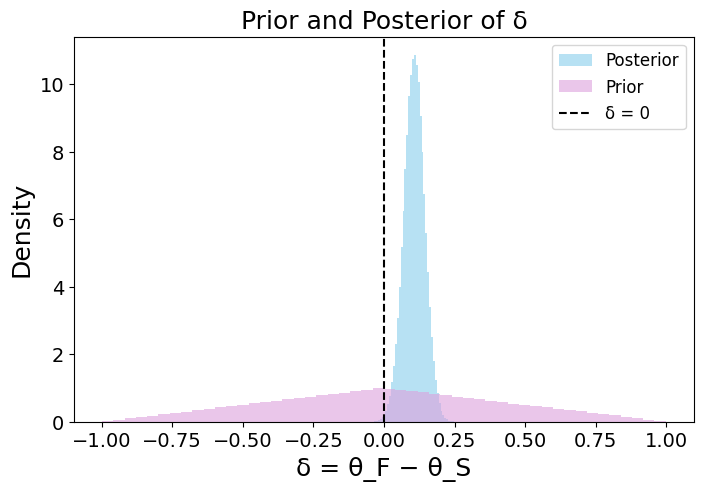

In [38]:
delta_prior_samples = samples['delta.prior'].flatten()
delta_posterior_samples = samples['delta'].flatten()

plt.figure(figsize=(8, 5))
ax = plt.gca()

ax.hist(delta_posterior_samples, bins=50, density=True, alpha=0.6, color='skyblue', label='Posterior')
ax.hist(delta_prior_samples, bins=50, density=True, alpha=0.6, color='plum', label='Prior')

ax.axvline(0, color='black', linestyle='dashed', linewidth=1.5, label='δ = 0')

ax.set_xlabel('δ = θ_F − θ_S')
ax.set_ylabel('Density')
ax.set_title('Prior and Posterior of δ')
ax.legend()
plt.show()


In order to compute the Savage-Dickey density ratio, we need to obtain the probabilities indicated at the value $\delta=0$ in these histograms. However, reading that with the naked eye from histograms is not particularly accurate. Instead, we shall use _kernel density estimation_. This technique smooths the histogram, but also allows us to query the probability density function that the histogram approximates, at any location of our choice. The function we use is `scipy.stats.gaussian_kde` (see https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.gaussian_kde.html). The term 'Gaussian' has to do with how it smooths the histogram, not with the distributions we use in our model!

2. Determine the PDFs of the posterior and the prior distributions $p(\delta \mid m_1)$ by applying the `gaussian_kde` function on the samples from your JAGS model. Plot these PDFs as a function from the whole possible range of $\delta$ ($\delta \in [-1, 1]$). Add a black dot at the points where the prior and the posterior intersect the vertical line where $\delta=0$, as implied by $m_0$ (you can add such a dot with `ax.plot(..., ..., 'o', color='k')`.

Note: The `p = gaussian_kde` function returns another function. This function is the approximated PDF, based on the samples you used. You can query `p` for example like `p([0.1, 0.2, 0.3])` or `p(np.linspace(0, 1, num=40)`. If you want to query it at one specific number, write: `p([number])` (note the square brackets).

_ANSWER:_

Bayes Factor: BF_10 = 5.620579025015514


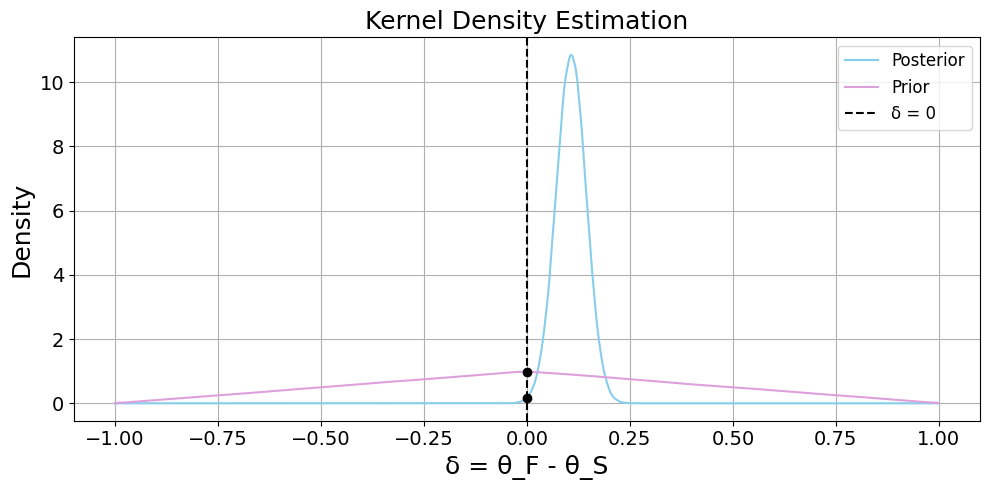

In [56]:
from scipy.stats import gaussian_kde

posterior = gaussian_kde(delta_posterior_samples)
prior = gaussian_kde(delta_prior_samples)

# the resolution of the linspace determines how smooth the plots are
delta_min, delta_max = -1.0, 1.0
delta_range = np.linspace(delta_min, delta_max, num=500)
delta_according_to_m0 = 0

posterior_pdf = posterior(delta_range)
prior_pdf = prior(delta_range)
#print(posterior_pdf.shape)
#print(prior_pdf.shape)

posterior_at_0 = posterior([delta_according_to_m0])[0] # the [0] at the end makes sure that its a float and not an array
prior_at_0 = prior([delta_according_to_m0])[0]

# Bayes Factor
BF_10 = prior_at_0 / posterior_at_0
print(f"Bayes Factor: BF_10 = {BF_10}")

# Plotting
plt.figure(figsize=(10, 5))
ax = plt.gca()

ax.plot(delta_range, posterior_pdf, label='Posterior', color='skyblue')
ax.plot(delta_range, prior_pdf, label='Prior', color='plum')

# plotting the dots at the intersection and the vertical line
ax.plot(delta_according_to_m0, posterior_at_0, 'o', color='black')
ax.plot(delta_according_to_m0, prior_at_0, 'o', color='black')
ax.axvline(delta_according_to_m0, linestyle='--', color='black', label='δ = 0')

ax.set_xlabel('δ = θ_F - θ_S')
ax.set_ylabel('Density')
ax.set_title(f'Kernel Density Estimation')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()


3. Now use the values at these black dots to compute the Bayes factor of the comparison using the Savage-Dickey approach. Is it close to the value you found with JAGS (let's call it close if they are within 10% of each other) in question 1.2.3?

Remember that both approaches are based on MCMC sampling; they are not exact. If you find results that are roughly within the same ballpark, but further than 10% apart, you might simply want to increase the number of JAGS samples. 

_ANSWER:_
The two Bayes factors that were computed are 5.79 (old BF) and 5.62 (BF with Savage-Dickey approach).
They are close to each other because they are within 10% of each other.

In [68]:
# already used in previous code but copied here for overview purposes
posterior = gaussian_kde(delta_posterior_samples)
prior = gaussian_kde(delta_prior_samples)
delta_according_to_m0 = 0
posterior_at_0 = posterior([delta_according_to_m0])[0]
prior_at_0 = prior([delta_according_to_m0])[0]

BF_10 = prior_at_0 / posterior_at_0

# Print all values for your answer
print(f"Prior at 0:  {prior_at_0}")
print(f"Posterior at 0:  {posterior_at_0}")
print(f"Bayes factor BF_10:  {BF_10}")
print(f"Previous BF_10: 5.785986936975143")


Prior at 0:  0.9823940288443873
Posterior at 0:  0.1747851999717548
Bayes factor BF_10:  5.620579025015514
Previous BF_10: 5.785986936975143


We saw in the lectures that in order to compute Bayes factors, we need marginal likelihoods, and that these are very sensitive to the prior distribution in a model. That applies here as well. 

Here, we explore what happens to the Bayes factor if we change the prior from extremely weak (uninformative) to extremely strong.

4. First, use the code template below to plot the prior and posterior for $m_1$ for different $q$ values of $a$ and $b$ (for simplicity, we keep $a=b$ here). Note that a `logspace` is used; so we explore values starting at 1, and ending with 1000, in logarithmically spaced steps. Explain what happens to the prior, and what happens to the posterior, as $a$ and $b$ are increased.

_ANSWER:_ 
As a and b are increased, the prior starts to become more narrow and higher. It starts very wide and low but towards the end it is a very sharp and high bell curve.
The posterior also becomes more narrow and higher, though not as much as the prior because it was rather high and narrow from the start. The center of the posterior shifts more towwards the delta=0 line.
The reason for these shifts is that as a and b increase, the prior becomes "stronger" and influences the posterior more, hence the shift towards delta = 0 for larger a and b.

sampling: iterations 200000 of 200000, elapsed 0:00:01, remaining 0:00:00
sampling: iterations 200000 of 200000, elapsed 0:00:01, remaining 0:00:00
sampling: iterations 200000 of 200000, elapsed 0:00:01, remaining 0:00:00
sampling: iterations 200000 of 200000, elapsed 0:00:01, remaining 0:00:00
sampling: iterations 200000 of 200000, elapsed 0:00:01, remaining 0:00:00
sampling: iterations 200000 of 200000, elapsed 0:00:01, remaining 0:00:00
sampling: iterations 200000 of 200000, elapsed 0:00:01, remaining 0:00:00
sampling: iterations 200000 of 200000, elapsed 0:00:01, remaining 0:00:00
sampling: iterations 200000 of 200000, elapsed 0:00:01, remaining 0:00:00
sampling: iterations 200000 of 200000, elapsed 0:00:01, remaining 0:00:00
sampling: iterations 200000 of 200000, elapsed 0:00:01, remaining 0:00:00
sampling: iterations 200000 of 200000, elapsed 0:00:01, remaining 0:00:00
sampling: iterations 200000 of 200000, elapsed 0:00:01, remaining 0:00:00
sampling: iterations 200000 of 200000,

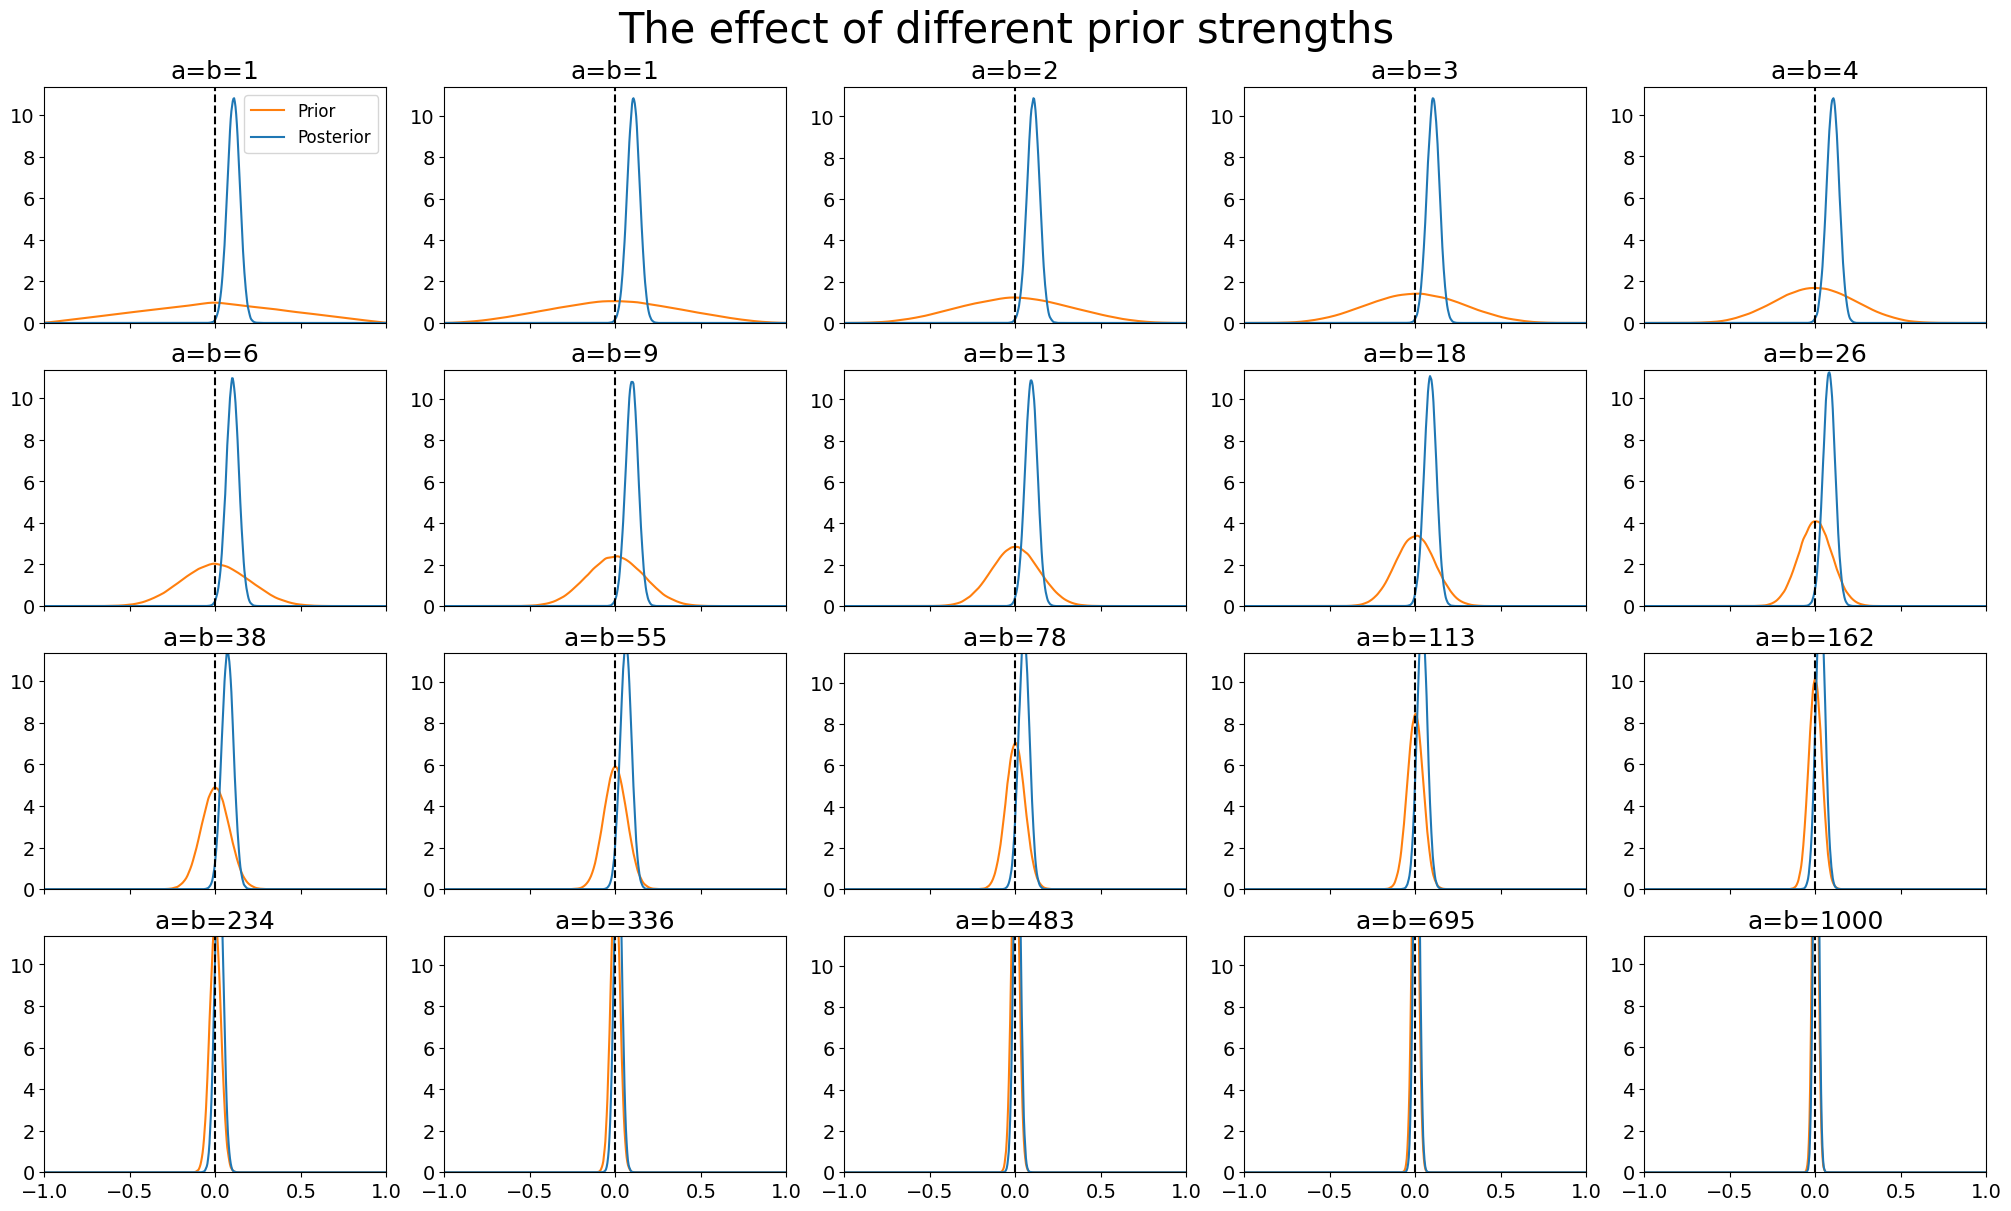

CPU times: user 1min 31s, sys: 7.95 s, total: 1min 39s
Wall time: 1min 27s


In [86]:
%%time
num_samples = 50000
num_chains = 4

q = 20
as_ = np.logspace(0, 3, num=q)
bs_ = np.logspace(0, 3, num=q)

delta_according_to_m0 = 0

_, axes = plt.subplots(nrows=4, ncols=5, sharex=True, sharey='col', 
                       constrained_layout=True, figsize=(20, 12))

for i, (a_, b_) in enumerate(zip(as_, bs_)):
    ax = axes.flatten()[i]  # plot in this axis

    data = {
        'N_F': N_F,
        'N_S': N_S,
        'x_F': x_F,
        'x_S': x_S,
        'a': a_,
        'b': b_
    }
    
    m_ = pj.Model(jags_model, data=data, chains=num_chains)
    samples_ = m_.sample(num_samples, vars=['delta', 'delta.prior'])
    posterior_ = gaussian_kde(samples_['delta'].flatten())
    prior_ = gaussian_kde(samples_['delta.prior'].flatten())
    
    # do the plotting here:

    delta_range = np.linspace(-1, 1, 500)
    posterior_pdf = posterior_(delta_range)
    prior_pdf = prior_(delta_range)

    ax.plot(delta_range, prior_pdf, color='tab:orange', label='Prior')
    ax.plot(delta_range, posterior_pdf, color='tab:blue', label='Posterior')
    ax.axvline(delta_according_to_m0, linestyle='--', color='k')
    ax.set_title(f'a=b={a_:.0f}')
    ax.set_xlim(-1, 1)
    ax.set_ylim(0, None)
    if i == 0:
        ax.legend()

plt.suptitle('The effect of different prior strengths')
plt.show()


5. Now make a single figure in which you plot the Bayes factor of this model comparison as a function of $a$ ($=b$) on the x-axis. You should see an initial increase in the Bayes factor, but then the Bayes factor decays to some asymptotic value. What is this value, and why does it make sense that the Bayes factor converges here, as we increase the strength of the prior? What does this mean for the model comparison?

_ANSWER_:

The value that the BF decays to is 1.
It makes sense that the BF converges there when increasing the strength of the prior because the actual data becomes less and less relevant and the prior is becoming more relevant.
But no matter how high a and b go, the prior and the posterior will be centered roughly in the same spot and this results in an inability to clearly support one model.
A BF of 1 shows that there is no evidence strongly supporting either model.
The models can be barely differentiated and so any evidence supporting one model would also equally support the other, hence you cannot tell which model is "better" and the BF converges to 1.

sampling: iterations 200000 of 200000, elapsed 0:00:01, remaining 0:00:00
sampling: iterations 200000 of 200000, elapsed 0:00:01, remaining 0:00:00
sampling: iterations 200000 of 200000, elapsed 0:00:01, remaining 0:00:00
sampling: iterations 200000 of 200000, elapsed 0:00:01, remaining 0:00:00
sampling: iterations 200000 of 200000, elapsed 0:00:01, remaining 0:00:00
sampling: iterations 200000 of 200000, elapsed 0:00:01, remaining 0:00:00
sampling: iterations 200000 of 200000, elapsed 0:00:01, remaining 0:00:00
sampling: iterations 200000 of 200000, elapsed 0:00:01, remaining 0:00:00
sampling: iterations 200000 of 200000, elapsed 0:00:01, remaining 0:00:00
sampling: iterations 200000 of 200000, elapsed 0:00:01, remaining 0:00:00
sampling: iterations 200000 of 200000, elapsed 0:00:01, remaining 0:00:00
sampling: iterations 200000 of 200000, elapsed 0:00:01, remaining 0:00:00
sampling: iterations 200000 of 200000, elapsed 0:00:01, remaining 0:00:00
sampling: iterations 200000 of 200000,

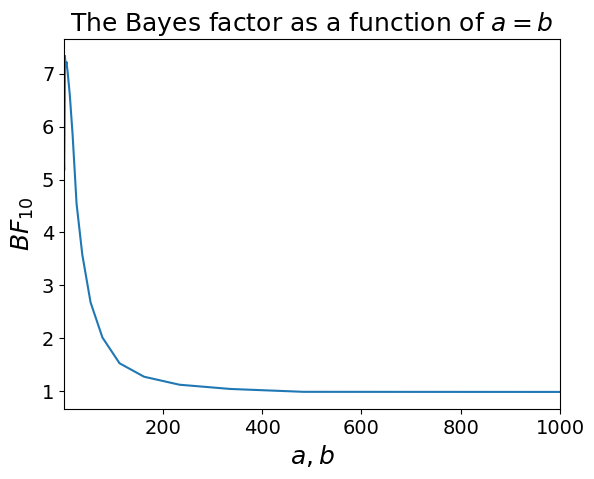

In [92]:
bfs = []

for a_ in as_:
    data = {
        'N_F': N_F,
        'N_S': N_S,
        'x_F': x_F,
        'x_S': x_S,
        'a': a_,
        'b': a_
    }
    
    m_ = pj.Model(jags_model, data=data, chains=num_chains)
    samples_ = m_.sample(num_samples, vars=['delta', 'delta.prior'])
    posterior_ = gaussian_kde(samples_['delta'].flatten())
    prior_ = gaussian_kde(samples_['delta.prior'].flatten())
    delta_according_to_m0 = 0
    prior_at_0 = prior_([delta_according_to_m0])[0]
    posterior_at_0 = posterior_([delta_according_to_m0])[0]

    bfs.append(prior_at_0 / posterior_at_0)

plt.figure()
ax = plt.gca()
ax.plot(as_, bfs)  # `bfs` is what you have to determine
ax.set_xlabel(r'$a, b$')
ax.set_ylabel(r'$BF_{10}$')
ax.set_xlim([1, 1000]);
ax.set_title('The Bayes factor as a function of $a=b$');

---
# 2. Time for a drink

After all this analysis for DentoCare, it is time to set our sights on a more enjoyable topic: booze. In this part of the exercise we'll study the quality of red wine ($y$), as a function of its chemical properties ($x$), such as pH, alcohol content, citric acid levels, and so on.

Our data set consists of $N=1599$ wines, and for each we have observed $p=11$ of these properties.

We'll try to figure out, using Bayesian testing, which of these properties are important for predicting wine quality, and which are not. To do so, we make use of the generalized linear model again, and describe our model as:

$$
    \begin{align}
        \beta_j &\sim \mathcal{N}(\beta_j \mid \mu_{\beta}, \sigma_{\beta}) && j=0, \ldots, p\\
        y_i \mid \mathbf{x}_i, \mathbf{\beta} &\sim \mathcal{N}(y_i \mid \beta_0 + \mathbf{x}_i^\top \mathbf{\beta}, \sigma_y) && i =1,\ldots, N\enspace,
    \end{align}
$$

Importantly, the quality of the wine is a linear combination of the chemical properties and the coefficients $\mathbf{\beta}$. Note that $\beta$ is a vector of $p+1$ elements, as it also contains the intercept $\beta_0$.

The code below loads the data, and makes a figure of the distribution of the feature and outcome values.

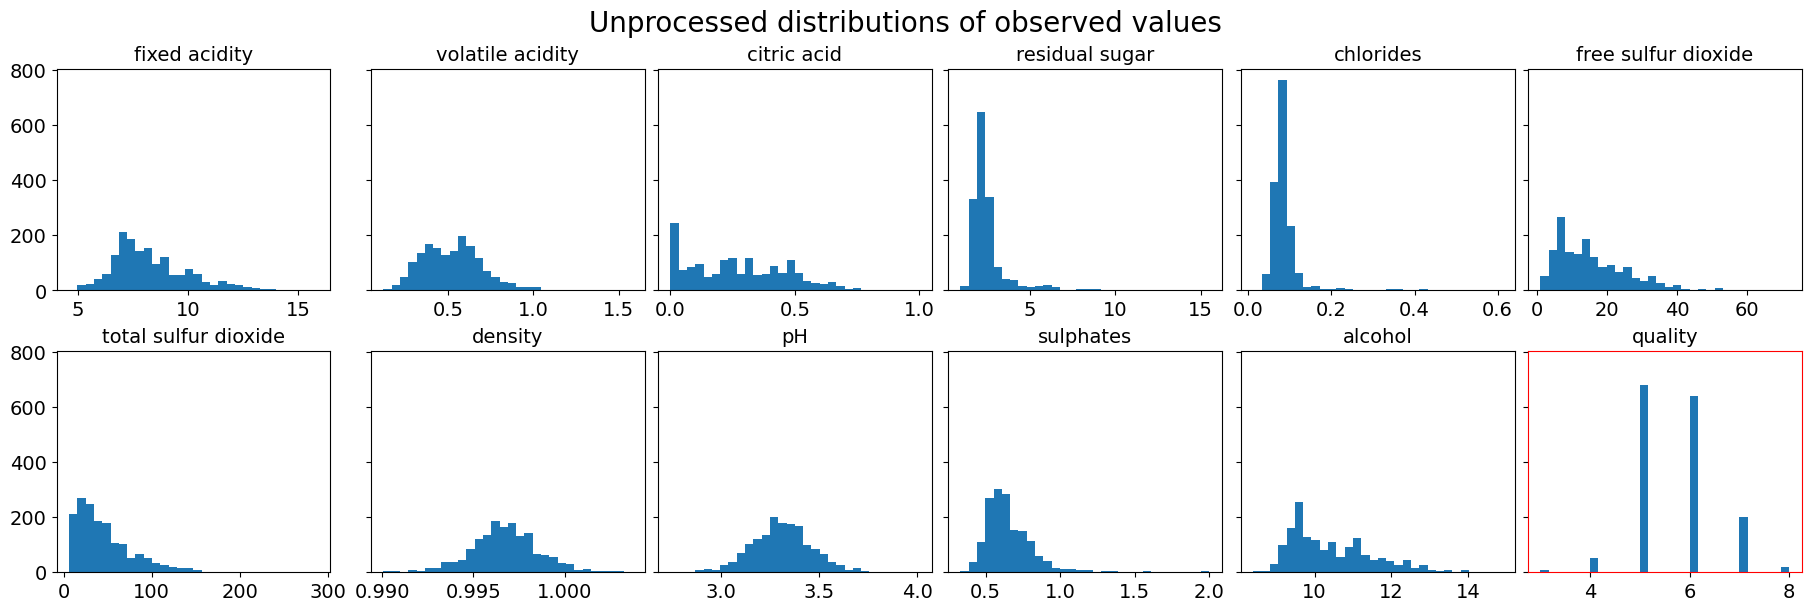

In [95]:
import pandas as pd
filename = 'winequality-red.csv'

df = pd.read_csv(filename, sep=';')
feature_names = df.columns
x = df.values[:, 0:-1]
y = df.values[:, -1]
n, p = x.shape

_, axes = plt.subplots(nrows=2, ncols=6, sharey=True, constrained_layout=True, 
                       figsize=(18, 6))

for i, ax in enumerate(axes.flatten()):
    if i < p:
        ax.hist(x[:, i], bins=30)
    else:
        ax.hist(y, bins=30)
    ax.set_title(feature_names[i], fontsize=14)

ax = axes.flatten()[-1]
for _, spine in ax.spines.items():
    spine.set_color('red')    
    spine.set_color('red')

plt.suptitle('Unprocessed distributions of observed values', fontsize=20);

**Practical note**: Notice how the different features have very different _ranges_ of possible values. For instance, the citric acid ranges from 0 to 0.7 (ish), whereas the alcohol percentage is in the range 9--14. This makes it hard to compare the regression coefficients $\beta$ with each other, as these coefficients will have to adjust to the scales of the corresponding predictor. For example, suppose the pH increases from 0.5 to 0.6, and let $\beta_{\text{pH}}=3.2$. This means a change in $y$ of $3.2(0.6-0.5) = 0.32$. If $\beta_{\text{alcohol}}=3.2$, and alcohol increases from 12% to 13%, then the change in $y$ is $3.2(13-12)=3.2$. A much bigger change in $y$, even though relatively speaking the predictors didn't change that much differently.

The standard data science approach to address this, is to standardize our input, so that every predictor has mean 0 and standard deviation 1. We shall adopt this approach here. 

1. Preprocess the features $x$ by, for each column of $x$, subtracting the mean $\mu(x)$ and dividing by the standard deviation $\sigma(x)$. Make another figure like the one above, but show the scaled versions of $x$. Make sure that indeed the mean of each histogram is now at 0. Do the same for the last observed value, the target wine quality $y$.

_ANSWER:_

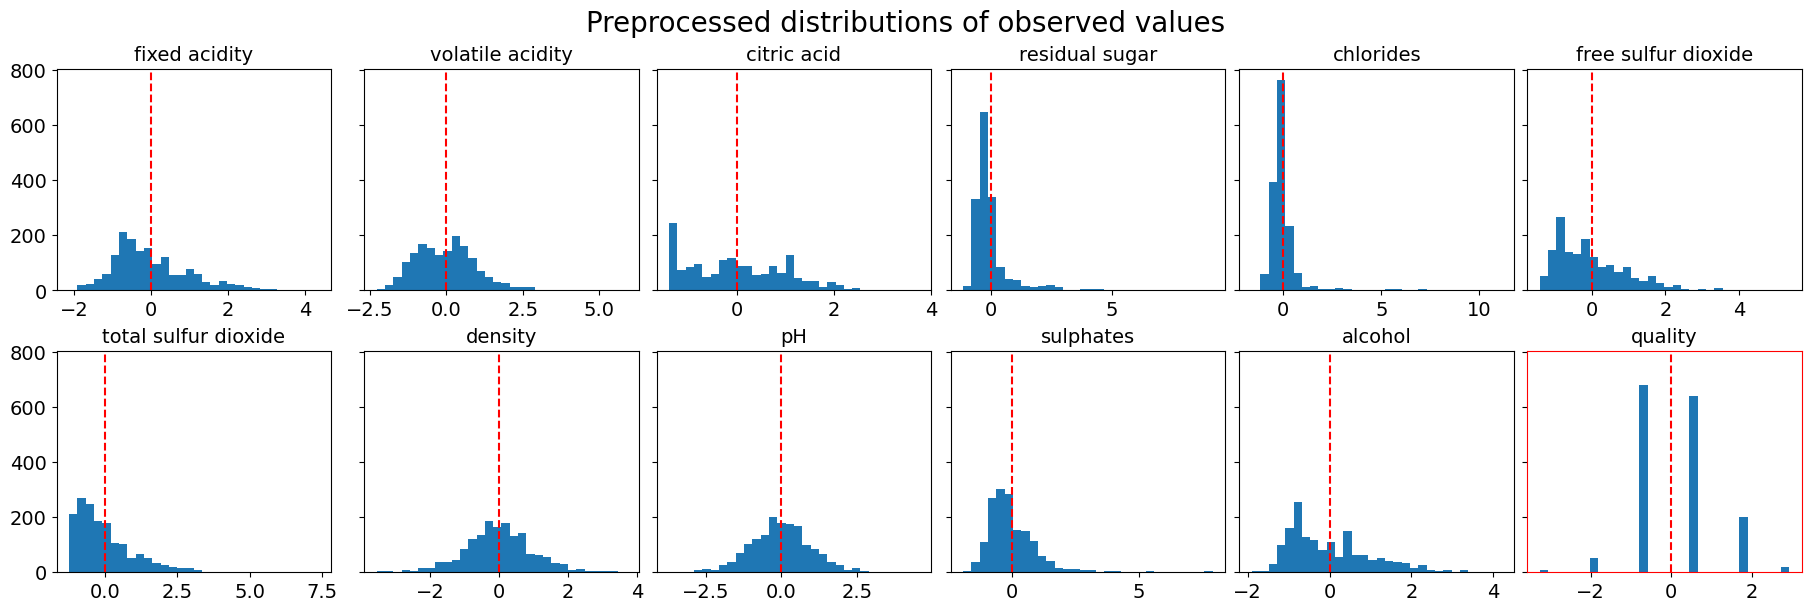

In [98]:
x = df.values[:, 0:-1]
x = (x - x.mean(axis=0)) / x.std(axis=0)
y = df.values[:, -1]
y = (y - y.mean()) / y.std()
n, p = x.shape

_, axes = plt.subplots(nrows=2, ncols=6, sharey=True, constrained_layout=True, 
                       figsize=(18, 6))

for i, ax in enumerate(axes.flatten()):
    if i < p:
        ax.hist(x[:, i], bins=30)
        ax.axvline(x[:, i].mean(), color='red', linestyle='--') # used for visualizing the mean (and checking for correctness)
    else:
        ax.hist(y, bins=30)
        ax.axvline(y.mean(), color='red', linestyle='--')
    ax.set_title(feature_names[i], fontsize=14)


ax = axes.flatten()[-1]
for _, spine in ax.spines.items():
    spine.set_color('red')    
    spine.set_color('red')

plt.suptitle('Preprocessed distributions of observed values', fontsize=20);

Now we can start constructing a Bayesian multiple regression model. 

**Practical note**: Clearly $y$ does not follow a Gaussian distribution, even after our transformation. For simplicity, we shall stick to Gaussians, but if you're using this exercise to buy your next wine, be warned that better modelling choices are available.

You have already done part of this in Large Assignment 1, and you are free to re-use your (**own!**) code from that assignment -- there is no need to reinvent the wheel if you are happy with that solution. However, we have several more predictors now though, so a linear algebra expression such as `inprod(...)` will be needed to make robust code.

2. Implement a Bayesian multiple linear regression model that predicts wine quality from the observed features, with the prior and likelihood as mentioned here. Make a figure showing for each of the 11 predictors $\beta_j, j=1, \ldots, p$ as well as intercept $\beta_0$ the approximate posterior distribution. Be sure to use the `inprod(...)` approach.


_ANSWER:_



In [66]:
%%time
jags_model = '''
model{      
  # Prior 
  for (j in 1:p) {
    beta[j] ~ dnorm(0, 1.0E-2)
  }
  beta0 ~ dnorm(0, 1.0E-2)

 

  # Likelihood
  for (i in 1:N) {
    mu[i] <- beta0 + inprod(beta[], X[i, ])
    y[i] ~ dnorm(mu[i], prec)
  }

   prec ~ dgamma(1.0E-3, 1.0E-3)
   sigma <- 1 / sqrt(prec)
}
'''

data = {
    'X': x.tolist(),  
    'y': y.tolist(),
    'N': x.shape[0],
    'p': x.shape[1]
}


num_samples = 20000
num_chains = 4
m = pj.Model(jags_model, data=data, chains=num_chains)

samples = m.sample(num_samples, vars=['beta0', 'beta', 'sigma'])
print('Sampling complete.')

sampling: iterations 6212 of 80000, elapsed 0:00:09, remaining 0:01:53
sampling: iterations 9480 of 80000, elapsed 0:00:15, remaining 0:01:49
sampling: iterations 15956 of 80000, elapsed 0:00:24, remaining 0:01:38
sampling: iterations 22496 of 80000, elapsed 0:00:34, remaining 0:01:28
sampling: iterations 29080 of 80000, elapsed 0:00:44, remaining 0:01:17
sampling: iterations 32404 of 80000, elapsed 0:00:49, remaining 0:01:12
sampling: iterations 35712 of 80000, elapsed 0:00:54, remaining 0:01:07
sampling: iterations 39016 of 80000, elapsed 0:00:59, remaining 0:01:02
sampling: iterations 42308 of 80000, elapsed 0:01:04, remaining 0:00:57
sampling: iterations 45592 of 80000, elapsed 0:01:09, remaining 0:00:52
sampling: iterations 48876 of 80000, elapsed 0:01:15, remaining 0:00:47
sampling: iterations 55432 of 80000, elapsed 0:01:24, remaining 0:00:37
sampling: iterations 62016 of 80000, elapsed 0:01:34, remaining 0:00:27
sampling: iterations 68612 of 80000, elapsed 0:01:44, remaining 0:

(1, 20000, 4)
(11, 20000, 4)
(80000, 1)
(80000, 11)


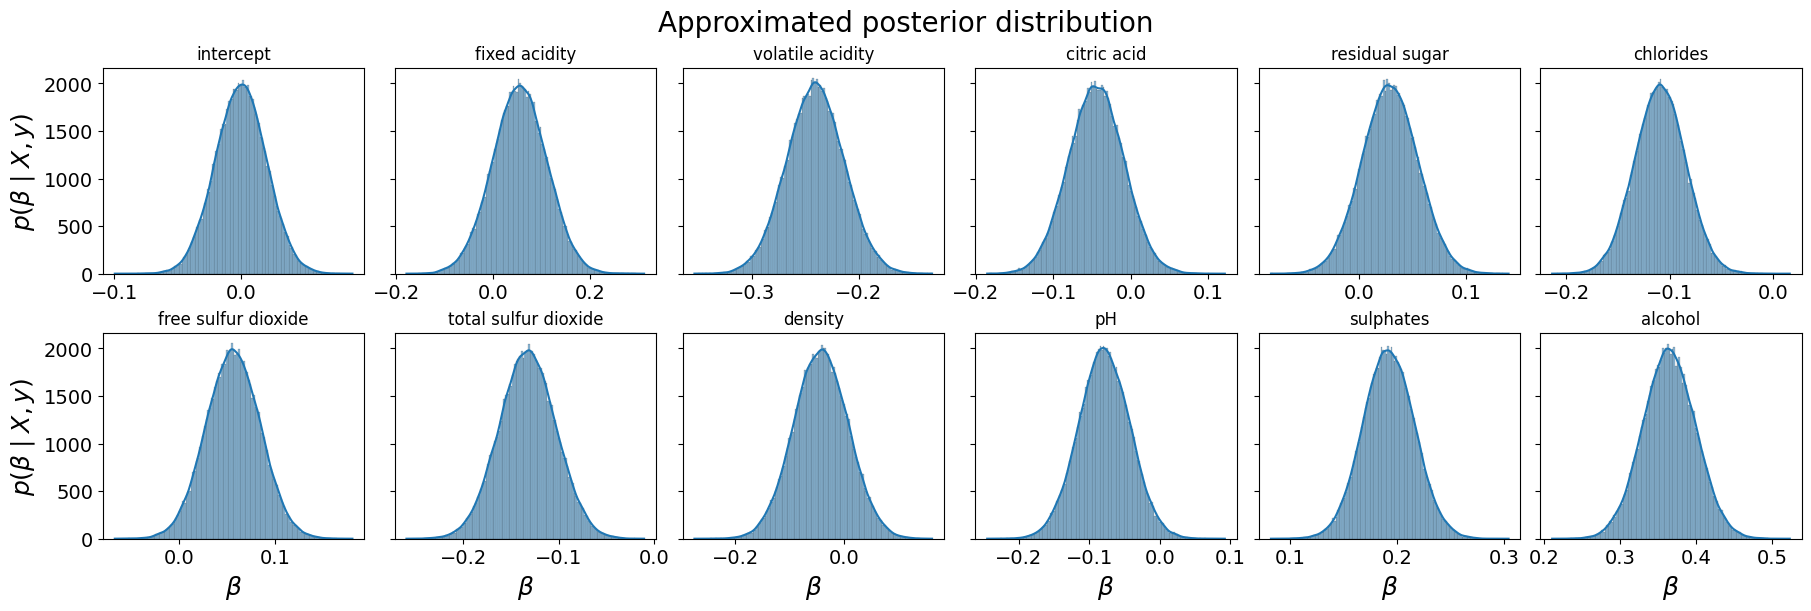

In [108]:
def get_hdi(s, intv=0.95):
    # probably useful for the next question...
    lower = np.percentile(s, (1 - intv) / 2 * 100)
    upper = np.percentile(s, (1 + intv) / 2 * 100)
    return lower, upper


#
import seaborn as sns
beta0_samples = samples['beta0']
beta_samples = samples['beta']  
print(beta0_samples.shape)
print(beta_samples.shape)

beta0_samples_reshaped = beta0_samples.reshape(-1, 1)
beta_samples_reshaped = np.transpose(beta_samples, (1, 2, 0)).reshape(-1, 11)
print(beta0_samples_reshaped.shape)
print(beta_samples_reshaped.shape)

combined_samples = np.hstack((beta0_samples_reshaped, beta_samples_reshaped))
names = ['intercept'] + list(feature_names[:-1])

_, axes = plt.subplots(nrows=2, ncols=6, sharey=True, constrained_layout=True, 
                       figsize=(18, 6))

for i, ax in enumerate(axes.flatten()):
    sns.histplot(combined_samples[:, i], kde=True, ax=ax)
    ax.set_title(names[i], fontsize=12)

for ax in axes[1, :]:
    ax.set_xlabel(r'$\beta$')
for ax in axes[:, 0]:
    ax.set_ylabel(r'$p(\beta \mid X, y)$')

plt.suptitle('Approximated posterior distribution', fontsize=20);


The question of 'which feature is important in predicting wine quality?' is also a form of model comparison / hypothesis testing. In a way, we are comparing $2^{11}$ models here -- because each of the $p=11$ predictors can either be important or not.

3. Use your posterior distributions to determine the 95% HDI for each of the predictors, and make a new figure where you show this interval on top of your posterior distributions. You can use, for example, the `ax.axvspan(..., alpha=0.2)` code. In addition, include a vertical line (with a clearly distinguishable color/linestyle) that represents for each predictor the null hypothesis that says this predictor is _not_ important (think about that this means for the corresponding $\beta$). According to this analysis, which features are important? Explain how you got to your answer.

_ANSWER:_
To determine whether a feature is important, the HDI plays a crucial role.
If 0 is included in the HDI, then the feature is most likely not important. SHould 0 be outside of the HDI, there is strong evidence in favor of a feature being important or in other words, there is strong evidence against null.
Based on this, every feature where the red line is outside of the HDI is important.
These features are: 'volatile acidity', 'chlorides', 'total sulphur dioxide', 'sulphates', 'alcohol'.
The features 'free sulfur dioxide' and 'pH' might be important but it is hard to see in the figure because the null line is right at the border of the HDI. They are probably not that important.

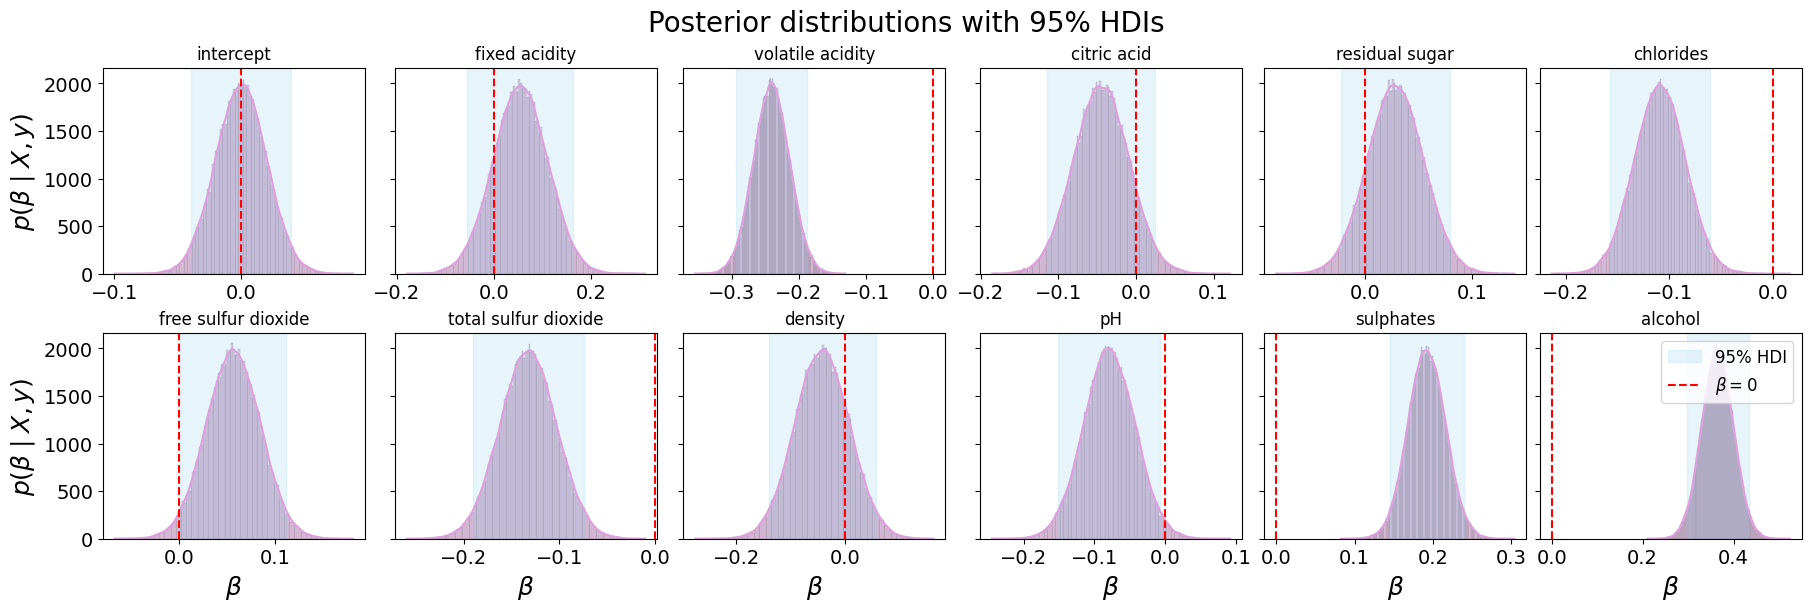

In [127]:
_, axes = plt.subplots(nrows=2, ncols=6, sharey=True, constrained_layout=True, figsize=(18, 6))

for i, ax in enumerate(axes.flatten()):
    param_samples = combined_samples[:, i]
    sns.histplot(param_samples, kde=True, ax=ax, color='plum')

    # adding hdi to plots
    hdi_low, hdi_high = get_hdi(param_samples)
    ax.axvspan(hdi_low, hdi_high, color='skyblue', alpha=0.2, label='95% HDI')

    ax.axvline(0, color='red', linestyle='--', label=r'$\beta = 0$')

    ax.set_title(names[i], fontsize=12)

# Axis labels
for ax in axes[1, :]:
    ax.set_xlabel(r'$\beta$')
for ax in axes[:, 0]:
    ax.set_ylabel(r'$p(\beta \mid X, y)$')

plt.suptitle('Posterior distributions with 95% HDIs', fontsize=20)
plt.legend(loc='upper right')
plt.show()


Your analysis has told us which features are important in predicting wine quality. However, a critical remark is that our choice of prior might affect our results.

4. Verify the robustness of your conclusion by changing the scale (=variance/standard deviation/precision) of the prior distribution on the regression coefficients. Do you find quantitatively different results (e.g., different conclusions)?

In [130]:
%%time
jags_model = '''
model{      
  # Prior 
  for (j in 1:p) {
    beta[j] ~ dnorm(0, 1.0E-4)
  }
  beta0 ~ dnorm(0, 1.0E-2)

 

  # Likelihood
  for (i in 1:N) {
    mu[i] <- beta0 + inprod(beta[], X[i, ])
    y[i] ~ dnorm(mu[i], prec)
  }

   prec ~ dgamma(1.0E-3, 1.0E-4)
   sigma <- 1 / sqrt(prec)
}
'''

data = {
    'X': x.tolist(),  
    'y': y.tolist(),
    'N': x.shape[0],
    'p': x.shape[1]
}


num_samples = 20000
num_chains = 4
m = pj.Model(jags_model, data=data, chains=num_chains)

samples = m.sample(num_samples, vars=['beta0', 'beta', 'sigma'])
print('Sampling complete.')
# Model 2 -> smaller precision

sampling: iterations 6448 of 80000, elapsed 0:00:10, remaining 0:01:53
sampling: iterations 9692 of 80000, elapsed 0:00:15, remaining 0:01:50
sampling: iterations 12876 of 80000, elapsed 0:00:21, remaining 0:01:48
sampling: iterations 15992 of 80000, elapsed 0:00:27, remaining 0:01:48
sampling: iterations 18944 of 80000, elapsed 0:00:33, remaining 0:01:46
sampling: iterations 21812 of 80000, elapsed 0:00:39, remaining 0:01:43
sampling: iterations 24640 of 80000, elapsed 0:00:44, remaining 0:01:38
sampling: iterations 30272 of 80000, elapsed 0:00:54, remaining 0:01:28
sampling: iterations 33092 of 80000, elapsed 0:00:59, remaining 0:01:23
sampling: iterations 38752 of 80000, elapsed 0:01:07, remaining 0:01:11
sampling: iterations 44532 of 80000, elapsed 0:01:16, remaining 0:01:01
sampling: iterations 50392 of 80000, elapsed 0:01:25, remaining 0:00:50
sampling: iterations 56296 of 80000, elapsed 0:01:35, remaining 0:00:40
sampling: iterations 62236 of 80000, elapsed 0:01:44, remaining 0:

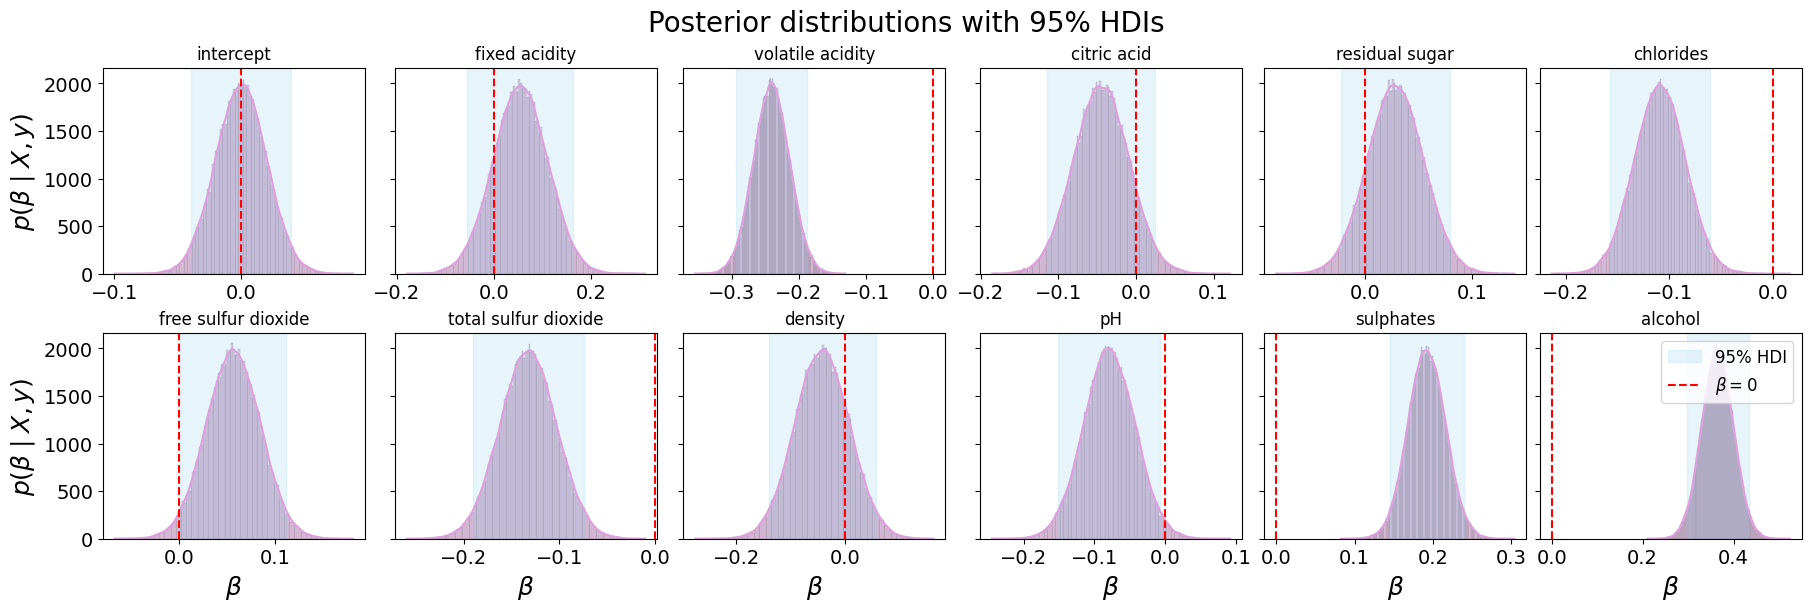

In [131]:
_, axes = plt.subplots(nrows=2, ncols=6, sharey=True, constrained_layout=True, figsize=(18, 6))

for i, ax in enumerate(axes.flatten()):
    param_samples = combined_samples[:, i]
    sns.histplot(param_samples, kde=True, ax=ax, color='plum')

    # adding hdi to plots
    hdi_low, hdi_high = get_hdi(param_samples)
    ax.axvspan(hdi_low, hdi_high, color='skyblue', alpha=0.2, label='95% HDI')

    ax.axvline(0, color='red', linestyle='--', label=r'$\beta = 0$')

    ax.set_title(names[i], fontsize=12)

# Axis labels
for ax in axes[1, :]:
    ax.set_xlabel(r'$\beta$')
for ax in axes[:, 0]:
    ax.set_ylabel(r'$p(\beta \mid X, y)$')

plt.suptitle('Posterior distributions with 95% HDIs', fontsize=20)
plt.legend(loc='upper right')
plt.show()

In [141]:

%%time
jags_model = '''
model{      
  # Prior 
  for (j in 1:p) {
    beta[j] ~ dnorm(0, 1)
  }
  beta0 ~ dnorm(0, 1.0E-2)

 

  # Likelihood
  for (i in 1:N) {
    mu[i] <- beta0 + inprod(beta[], X[i, ])
    y[i] ~ dnorm(mu[i], prec)
  }

   prec ~ dgamma(1.0E-3, 1)
   sigma <- 1 / sqrt(prec)
}
'''

data = {
    'X': x.tolist(),  
    'y': y.tolist(),
    'N': x.shape[0],
    'p': x.shape[1]
}


num_samples = 20000
num_chains = 4
m = pj.Model(jags_model, data=data, chains=num_chains)

samples = m.sample(num_samples, vars=['beta0', 'beta', 'sigma'])
print('Sampling complete.')

# Model 3 -> larger precision

sampling: iterations 6252 of 80000, elapsed 0:00:09, remaining 0:01:45
sampling: iterations 9756 of 80000, elapsed 0:00:14, remaining 0:01:42
sampling: iterations 16688 of 80000, elapsed 0:00:24, remaining 0:01:31
sampling: iterations 20148 of 80000, elapsed 0:00:30, remaining 0:01:28
sampling: iterations 23552 of 80000, elapsed 0:00:36, remaining 0:01:25
sampling: iterations 30184 of 80000, elapsed 0:00:46, remaining 0:01:15
sampling: iterations 36820 of 80000, elapsed 0:00:55, remaining 0:01:05
sampling: iterations 40152 of 80000, elapsed 0:01:01, remaining 0:01:00
sampling: iterations 43460 of 80000, elapsed 0:01:06, remaining 0:00:56
sampling: iterations 46744 of 80000, elapsed 0:01:13, remaining 0:00:52
sampling: iterations 49940 of 80000, elapsed 0:01:19, remaining 0:00:47
sampling: iterations 53108 of 80000, elapsed 0:01:24, remaining 0:00:43
sampling: iterations 59428 of 80000, elapsed 0:01:33, remaining 0:00:32
sampling: iterations 65804 of 80000, elapsed 0:01:43, remaining 0:

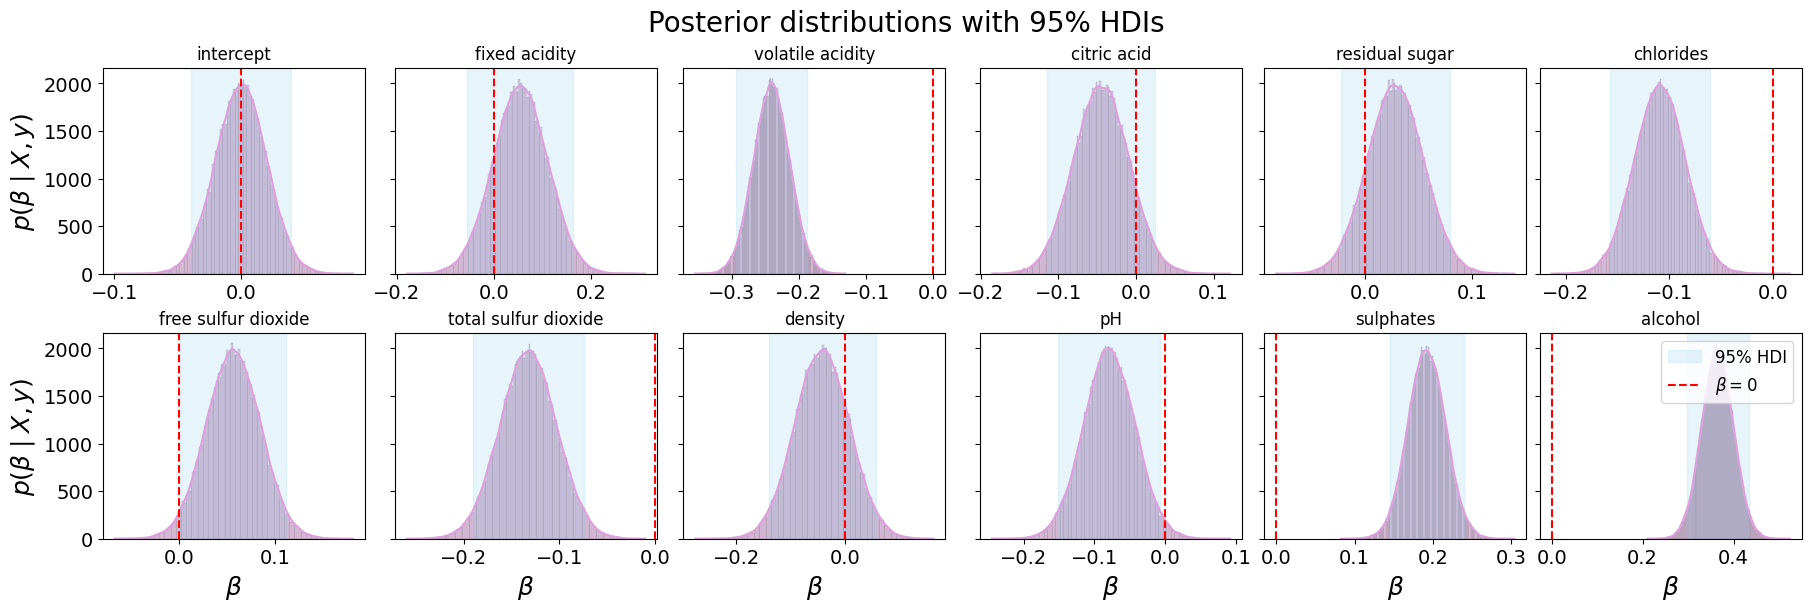

In [148]:
_, axes = plt.subplots(nrows=2, ncols=6, sharey=True, constrained_layout=True, figsize=(18, 6))

for i, ax in enumerate(axes.flatten()):
    param_samples = combined_samples[:, i]
    sns.histplot(param_samples, kde=True, ax=ax, color='plum')

    # adding hdi to plots
    hdi_low, hdi_high = get_hdi(param_samples)
    ax.axvspan(hdi_low, hdi_high, color='skyblue', alpha=0.2, label='95% HDI')

    ax.axvline(0, color='red', linestyle='--', label=r'$\beta = 0$')

    ax.set_title(names[i], fontsize=12)

# Axis labels
for ax in axes[1, :]:
    ax.set_xlabel(r'$\beta$')
for ax in axes[:, 0]:
    ax.set_ylabel(r'$p(\beta \mid X, y)$')

plt.suptitle('Posterior distributions with 95% HDIs', fontsize=20)
plt.legend(loc='upper right')
plt.show()

_ANSWER:_ 
We tried to more models with different precisions (one smaller and one larger).
We could not spot any differences, therefore the conclusion seems rather robust.

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=b076f4e6-863b-45d6-a4d3-a3de5d93b110' target="_blank">
 </img>
Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>